## Import library

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import joblib

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

**Sumber Dataset:** Zenodo https://zenodo.org/records/6616632  
**Pembuat:** Maltezos, Evangelos, dkk.  
**Konteks Dataset:** Data ini direkam dari sistem sensor *Smart Building* (SB112) yang menggunakan komputasi *edge* (Edge Computing). Dataset ini sangat ideal untuk melatih model deteksi dini anomali lingkungan (kebakaran dan kebocoran gas) menggunakan pendekatan multi-modal berbasis IoT.

------------------------------------------------------------------------------------------------------------------------------------
#### Karakteristik File dan Fitur 
Dataset mentah terdiri dari 5 dokumen terpisah yang mewakili masing-masing sensor. Setiap observasi dalam dataset ini memiliki 4 kolom utama:
* `time`: Waktu pencatatan data (*timestamp*) spesifik saat sensor merekam kondisi lingkungan, lengkap dengan zona waktu. Waktu rekam antar sensor bersifat asinkron (tidak bersamaan persis).
* `data_type`: Jenis sensor yang melakukan perekaman (CNG, CO, Flame_presence, LPG, Smoke).
* `unit`: Satuan pengukuran dari nilai yang dihasilkan (contoh: `ppm` untuk konsentrasi gas/asap, dan `raw values` untuk deteksi api).
* `data_value`: Nilai kuantitatif pembacaan sensor. (Catatan: Nilai asli direkam dalam format notasi ilmiah dengan koma Eropa, misal: `2,36E+01`).

#### Parameter Sensor IoT
Sistem pemantauan ini mendeteksi anomali melalui 5 parameter lingkungan yang berbeda:
1.  **Sensor CNG (Compressed Natural Gas):** Mengukur konsentrasi kebocoran gas alam di udara.
2.  **Sensor CO (Carbon Monoxide):** Mendeteksi kadar gas beracun yang biasanya timbul dari pembakaran tidak sempurna.
3.  **Sensor LPG (Liquefied Petroleum Gas):** Mengukur konsentrasi gas cair/elpiji.
4.  **Sensor Smoke:** Membaca tingkat ketebalan atau kepekatan asap di udara.
5.  **Sensor Flame/IR:** Menangkap keberadaan titik api atau radiasi inframerah dari nyala api terbuka.

#### Skenario Perekaman dan *Ground Truth* 
Proses perekaman data dilakukan secara berlanjut selama 4 hari, yakni dari tanggal **08 Maret 2022 hingga 11 Maret 2022**. Pembuat dataset telah mendefinisikan skenario perekaman yang menjadi acuan pembuatan target kelas (*Supervised Learning*):

* **Kelas Normal / Negatif (08/03/2022 - 10/03/2022):** Sistem dibiarkan berjalan terus-menerus tanpa adanya pemicu (*trigger*) fisik dari luar. Rentang waktu ini murni merepresentasikan kondisi ruangan yang aman dan stabil.
* **Kelas Anomali / Positif (11/03/2022):** Dilakukan simulasi kebocoran dan kebakaran secara fisik untuk memicu respons sensor, dengan rincian tindakan:
    * Membakar secarik kertas pada jarak 15 - 20 cm dari sensor Asap dan CO.
    * Mengekspos sensor LPG/CNG dengan gas korek api pada jarak 5 - 10 cm.
    * Menggerakkan nyala api dari korek pada jarak 15 - 100 cm untuk menguji sensor Flame/IR.

Berdasarkan skenario kronologis di atas, pemisahan target fitur dapat dilakukan secara deterministik berdasarkan tanggal rekaman (*timestamp*).

***

## Data understanding

### Raw Data

In [6]:
df_Cng = pd.read_csv('smoke_dataset/dataset/cng_sensor.csv', delimiter=';')
df_Cng.head()

,time,data_type,unit,data_value
0,2022-03-08T12:38:48.81+02:00,CNG,ppm,"2,36E+01"
1,2022-03-08T12:39:08.47+02:00,CNG,ppm,"2,13E+01"
2,2022-03-08T12:39:29.53+02:00,CNG,ppm,"2,12E+01"
3,2022-03-08T12:39:48.82+02:00,CNG,ppm,"2,26E+01"
4,2022-03-08T12:40:16.88+02:00,CNG,ppm,"2,13E+01"


In [7]:
df_Co = pd.read_csv('smoke_dataset/dataset/co_sensor.csv', delimiter=';')
df_Co.head()

,time,data_type,unit,data_value
0,2022-03-08T12:39:00.63+02:00,CO,ppm,"8,98E-01"
1,2022-03-08T12:39:20.98+02:00,CO,ppm,"9,73E-01"
2,2022-03-08T12:39:47.76+02:00,CO,ppm,"9,22E-01"
3,2022-03-08T12:40:07.18+02:00,CO,ppm,"9,00E-01"
4,2022-03-08T12:40:27.80+02:00,CO,ppm,"9,32E-01"


In [8]:
df_flame = pd.read_csv('smoke_dataset/dataset/flame_sensor.csv', delimiter=';')
df_flame.head()

,time,data_type,unit,data_value
0,2022-03-08T12:38:57.12+02:00,Flame_presence,raw values,"6,64E-01"
1,2022-03-08T12:39:17.40+02:00,Flame_presence,raw values,"4,00E-01"
2,2022-03-08T12:39:38.30+02:00,Flame_presence,raw values,"8,51E-01"
3,2022-03-08T12:39:57.70+02:00,Flame_presence,raw values,"7,64E-01"
4,2022-03-08T12:40:17.88+02:00,Flame_presence,raw values,"4,41E-01"


In [9]:
df_lpg = pd.read_csv('smoke_dataset/dataset/lpg_sensor.csv', delimiter=';')
df_lpg.head()

,time,data_type,unit,data_value
0,2022-03-08T12:38:49.39+02:00,LPG,ppm,"2,50E+01"
1,2022-03-08T12:39:08.49+02:00,LPG,ppm,"2,43E+01"
2,2022-03-08T12:39:37.76+02:00,LPG,ppm,"2,39E+01"
3,2022-03-08T12:39:49.36+02:00,LPG,ppm,"2,37E+01"
4,2022-03-08T12:40:16.49+02:00,LPG,ppm,"2,51E+01"


In [10]:
df_smoke = pd.read_csv('smoke_dataset/dataset/smoke_sensor.csv', delimiter=';')
df_smoke.head()

,time,data_type,unit,data_value
0,2022-03-08T12:39:00.61+02:00,Smoke,ppm,"1,46E+01"
1,2022-03-08T12:39:20.73+02:00,Smoke,ppm,"1,57E+01"
2,2022-03-08T12:39:47.36+02:00,Smoke,ppm,"1,53E+01"
3,2022-03-08T12:40:06.85+02:00,Smoke,ppm,"1,62E+01"
4,2022-03-08T12:40:27.44+02:00,Smoke,ppm,"1,53E+01"


In [11]:
df_dataset = pd.read_csv('smoke_dataset/clean_dataset/dataset_fixed.csv', delimiter=',')
df_dataset.head()

,time,cng,lpg,smoke,flame,co,target
0,2022-03-08 12:39:01,23.6,25.0,14.6,0.664,0.898,0
1,2022-03-08 12:39:02,23.6,25.0,14.6,0.664,0.898,0
2,2022-03-08 12:39:03,23.6,25.0,14.6,0.664,0.898,0
3,2022-03-08 12:39:04,23.6,25.0,14.6,0.664,0.898,0
4,2022-03-08 12:39:05,23.6,25.0,14.6,0.664,0.898,0


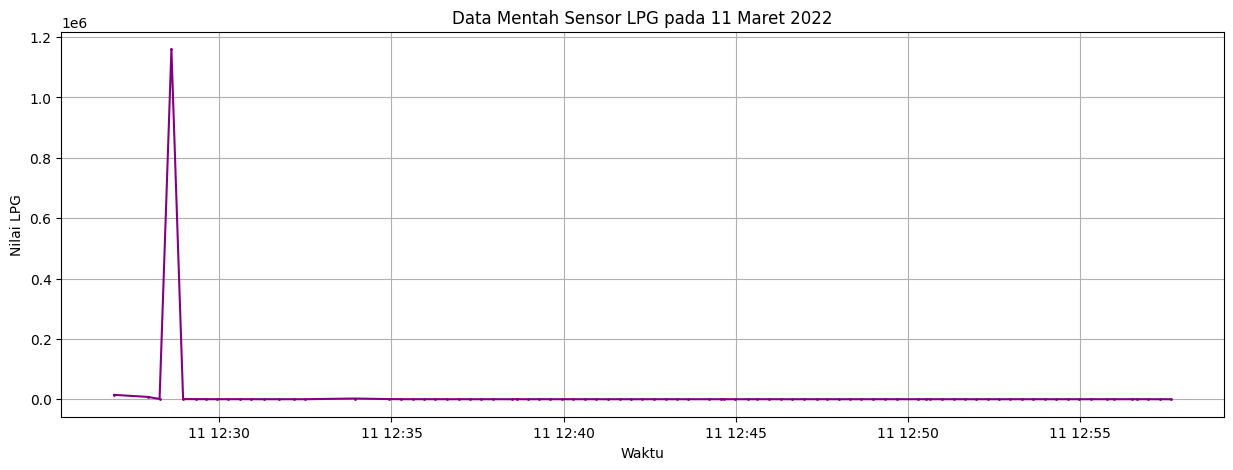

In [12]:
df_lpg['time'] = pd.to_datetime(df_lpg['time'])
df_lpg['data_value'] = df_lpg['data_value'].str.replace(',', '.').astype(float)
df_lpg_11maret = df_lpg[df_lpg['time'].dt.date == pd.to_datetime('2022-03-11').date()]

# 5. Buat visualisasi garis (Line Chart)
plt.figure(figsize=(15, 5))
plt.plot(df_lpg_11maret['time'], df_lpg_11maret['data_value'], color='purple', marker='.', markersize=2)
plt.title('Data Mentah Sensor LPG pada 11 Maret 2022')
plt.xlabel('Waktu')
plt.ylabel('Nilai LPG')
plt.grid(True)
plt.show()

### Join data

In [13]:
def gabungkan_semua_sensor():
    print("=== Memulai Proses Penggabungan Data Sensor IoT ===")
    dataframes = []
    daftar_file = glob.glob('smoke_dataset/dataset/*_sensor.csv')
    if not daftar_file:
        print("Error: Tidak ditemukan file berakhiran '_sensor.csv' di direktori ini.")
        return

    for file in daftar_file:
        nama_sensor = os.path.basename(file).split('_')[0].lower()
        print(f"-> Membaca dan memproses data: {nama_sensor.upper()} ...")
        df = pd.read_csv(file, sep=';', decimal=',')
        
        df['time'] = pd.to_datetime(df['time']).dt.tz_localize(None).dt.round('S')
        df.drop_duplicates(subset=['time'], keep='first', inplace=True)
        df.set_index('time', inplace=True)
        df_sensor = df[['data_value']].astype(float).rename(columns={'data_value': nama_sensor})
        
        dataframes.append(df_sensor)
    print("\n-> Semua file berhasil dibaca. Menggabungkan data berdasarkan detik waktu...")
    df_gabungan = pd.concat(dataframes, axis=1)
    
    # Urutkan dari waktu terlama ke terbaru
    df_gabungan.sort_index(inplace=True)
    
    print("-> Merapikan data bolong (Handling Missing Values)...")
    # Resample per 1 detik agar rentang waktunya solid dan konsisten
    df_gabungan = df_gabungan.resample('1S').mean()
    
    # Forward-fill 
    df_gabungan = df_gabungan.ffill(limit=30)
    df_gabungan.dropna(inplace=True)    
    df_gabungan.reset_index(inplace=True)
    
    print(f"\n=== Proses Selesai ===")
    print(f"Total baris data bersih dan selaras: {len(df_gabungan)}")
    print("Sample 5 data pertama:")
    print(df_gabungan.head())
    
    nama_file_output = 'smoke_dataset/eksperiment/ETL.csv'
    df_gabungan.to_csv(nama_file_output, index=False)
    print(f"\n[SUKSES] Dataset final berhasil disimpan sebagai '{nama_file_output}'")

if __name__ == "__main__":
    gabungkan_semua_sensor()

=== Memulai Proses Penggabungan Data Sensor IoT ===
-> Membaca dan memproses data: CNG ...
-> Membaca dan memproses data: LPG ...
-> Membaca dan memproses data: SMOKE ...
-> Membaca dan memproses data: FLAME ...
-> Membaca dan memproses data: CO ...

-> Semua file berhasil dibaca. Menggabungkan data berdasarkan detik waktu...
-> Merapikan data bolong (Handling Missing Values)...

=== Proses Selesai ===
Total baris data bersih dan selaras: 176687
Sample 5 data pertama:
                 time   cng   lpg  smoke  flame     co
0 2022-03-08 12:39:01  23.6  25.0   14.6  0.664  0.898
1 2022-03-08 12:39:02  23.6  25.0   14.6  0.664  0.898
2 2022-03-08 12:39:03  23.6  25.0   14.6  0.664  0.898
3 2022-03-08 12:39:04  23.6  25.0   14.6  0.664  0.898
4 2022-03-08 12:39:05  23.6  25.0   14.6  0.664  0.898


/var/folders/mw/0ktg0s2n021d3v7pjlsk81sc0000gp/T/ipykernel_67654/2588262993.py:14: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['time'] = pd.to_datetime(df['time']).dt.tz_localize(None).dt.round('S')
/var/folders/mw/0ktg0s2n021d3v7pjlsk81sc0000gp/T/ipykernel_67654/2588262993.py:14: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['time'] = pd.to_datetime(df['time']).dt.tz_localize(None).dt.round('S')
/var/folders/mw/0ktg0s2n021d3v7pjlsk81sc0000gp/T/ipykernel_67654/2588262993.py:14: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['time'] = pd.to_datetime(df['time']).dt.tz_localize(None).dt.round('S')
/var/folders/mw/0ktg0s2n021d3v7pjlsk81sc0000gp/T/ipykernel_67654/2588262993.py:14: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['time'] = pd.to_datetime(df['time']).dt.


[SUKSES] Dataset final berhasil disimpan sebagai 'smoke_dataset/eksperiment/ETL.csv'


### Sebaran data sensor 

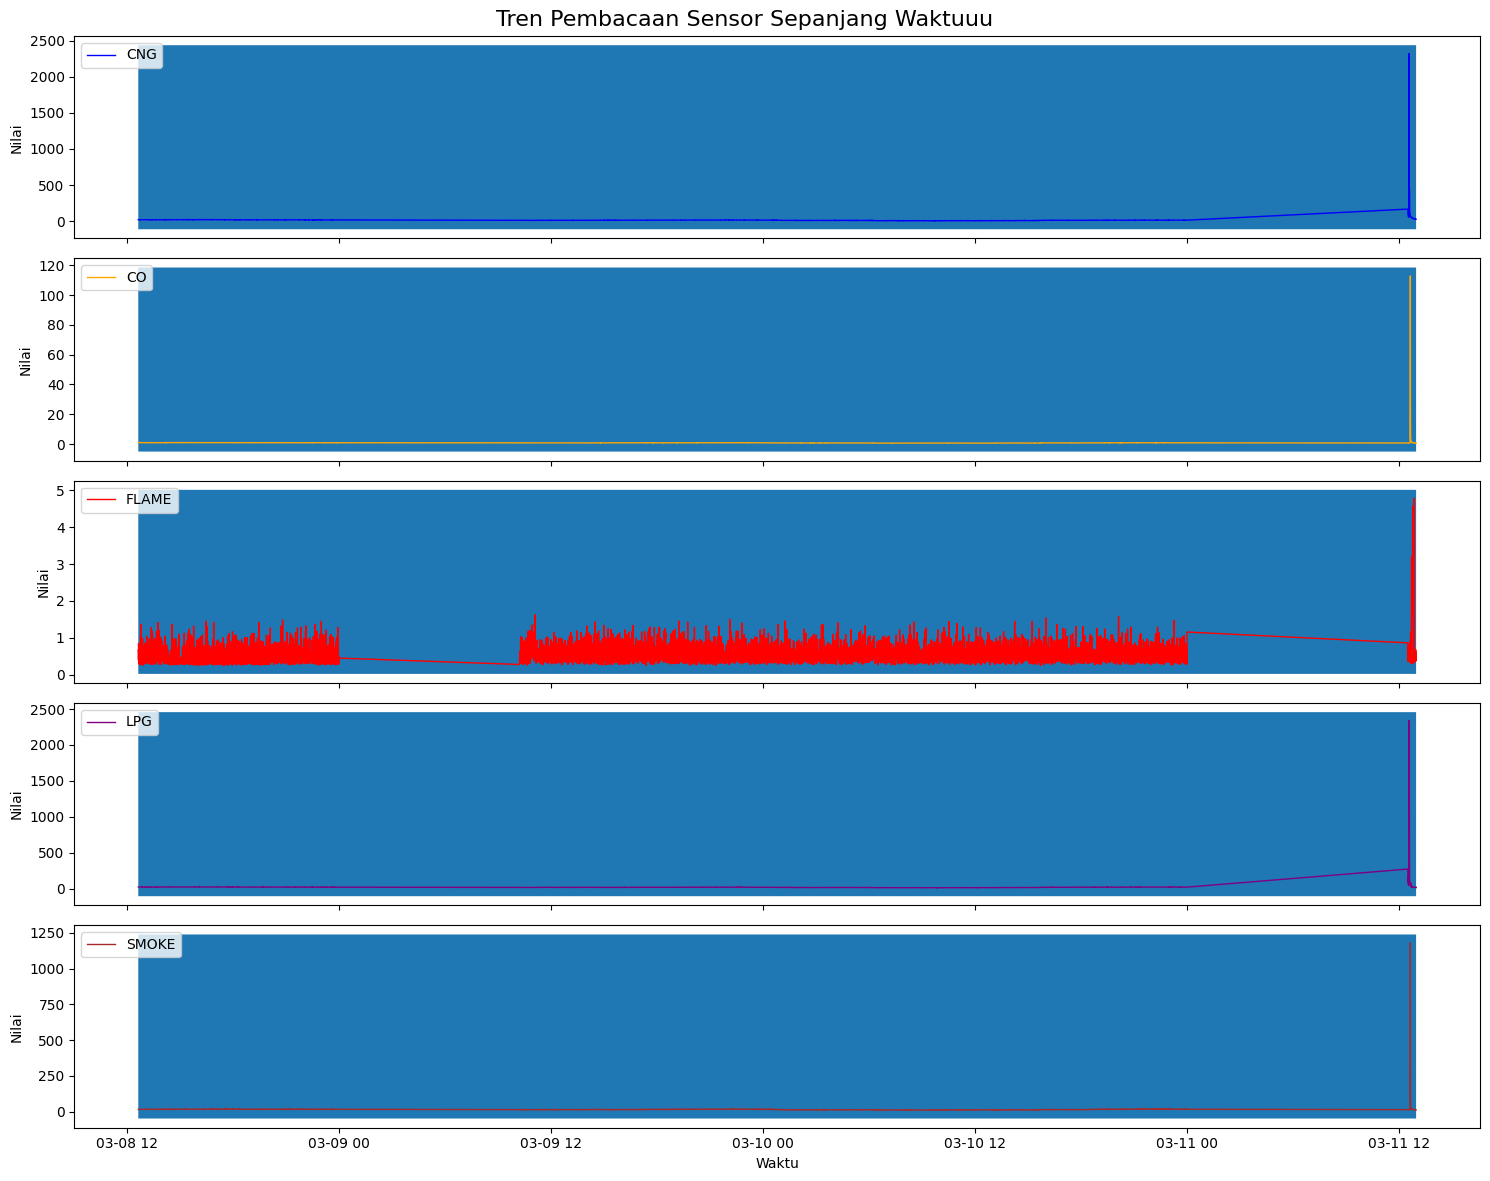

In [14]:
df = pd.read_csv('smoke_dataset/eksperiment/ETL.csv', index_col=0, parse_dates=True)

fig, axes = plt.subplots(5, 1, figsize=(15, 12), sharex=True)
sensors = ['cng', 'co', 'flame', 'lpg', 'smoke']
colors = ['blue', 'orange', 'red', 'purple', 'brown']

for i, sensor in enumerate(sensors):
    axes[i].plot(df.index, df[sensor], label=sensor.upper(), color=colors[i], linewidth=1)
    
    # Memberi warna latar (highlight) merah pada area yang label targetnya = 1 (Bahaya)
    axes[i].fill_between(df.index, axes[i].get_ylim()[0], axes[i].get_ylim()[1])
    
    axes[i].set_ylabel('Nilai')
    axes[i].legend(loc='upper left')

plt.suptitle('Tren Pembacaan Sensor Sepanjang Waktuuu', fontsize=16)
plt.xlabel('Waktu')
plt.tight_layout()

In [22]:
df = pd.read_csv('smoke_dataset/eksperiment/ETL.csv') 

df['time'] = pd.to_datetime(df['time']).dt.tz_localize(None)

df_normal = df[df['time'] < '2022-03-11'].copy()

fitur = ['cng', 'co', 'flame', 'lpg', 'smoke']
X_train_murni = df_normal[fitur]

print(f"Data Normal yang digunakan untuk training: {len(X_train_murni)} detik (Dari tgl 8, 9, 10)")


Data Normal yang digunakan untuk training: 175105 detik (Dari tgl 8, 9, 10)


## Data Preparation

In [23]:
# 1. Normalisasi skala sensor
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_murni)


## Training & Evaluation

In [32]:
iso_forest = IsolationForest(n_estimators=100, 
                             contamination=0.0001, 
                             random_state=42, 
                             n_jobs=-1)

print("Mulai melatih AI mengenali kondisi ruangan kosong")
iso_forest.fit(X_scaled)
print("Training Selesai! Model sudah hafal pola ruangan yang aman.")

Mulai melatih AI mengenali kondisi ruangan kosong
Training Selesai! Model sudah hafal pola ruangan yang aman.


=== Laporan Klasifikasi Isolation Forest ===
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00    175365
 Anomali (1)       0.98      0.45      0.61      1322

    accuracy                           1.00    176687
   macro avg       0.99      0.72      0.81    176687
weighted avg       1.00      1.00      1.00    176687



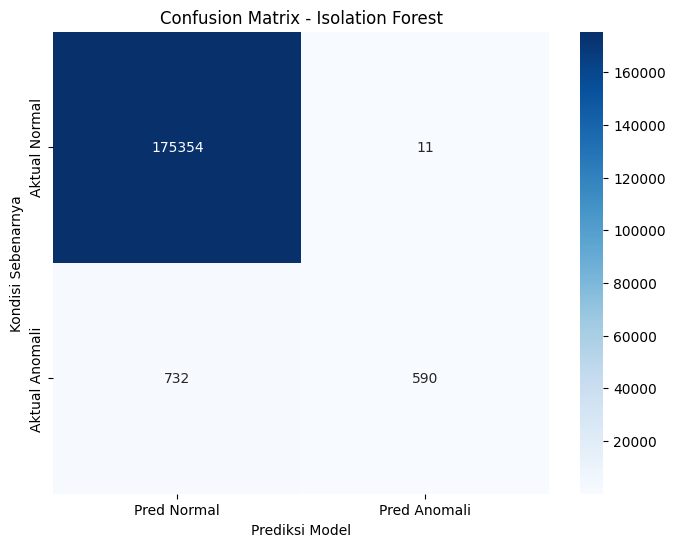

In [ ]:
df_eval = pd.read_csv('smoke_dataset/clean_dataset/dataset_fixed.csv', delimiter=',')

y_true = df_eval['target']
fitur = ['cng', 'co', 'flame', 'lpg', 'smoke']
X_eval = df_eval[fitur]

X_eval_scaled = scaler.transform(X_eval)
y_pred_iso = iso_forest.predict(X_eval_scaled)

y_pred = np.where(y_pred_iso == -1, 1, 0)

# ==========================================
# 7. CETAK HASIL EVALUASI
# ==========================================
print("=== Laporan Klasifikasi Isolation Forest ===")
print(classification_report(y_true, y_pred, target_names=['Normal (0)', 'Anomali (1)']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred Normal', 'Pred Anomali'], 
            yticklabels=['Aktual Normal', 'Aktual Anomali'])
plt.title('Confusion Matrix - Isolation Forest')
plt.xlabel('Prediksi Model')
plt.ylabel('Kondisi Sebenarnya')
plt.show()

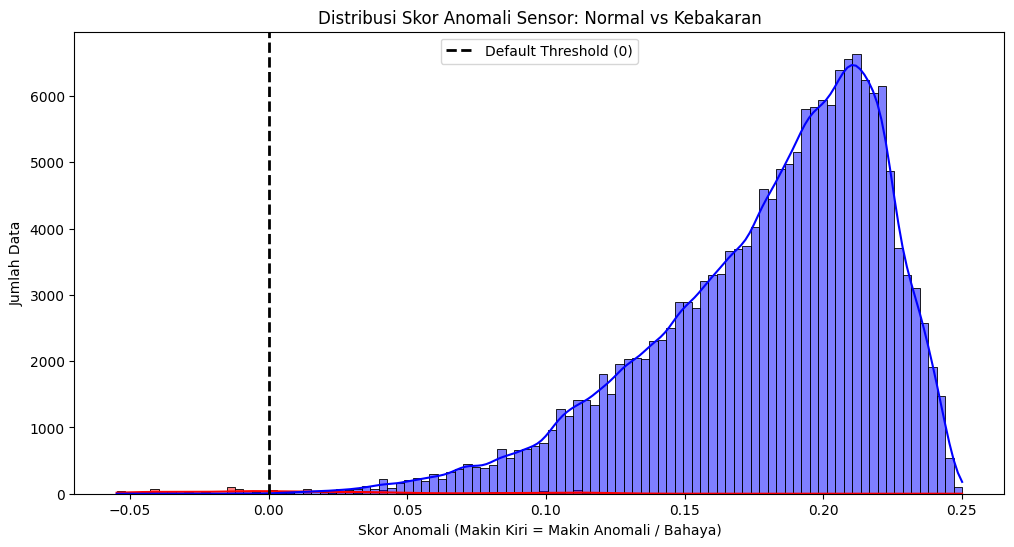

In [34]:
# 1. Dapatkan skor anomali berupa angka kontinu dari model
skor_anomali = iso_forest.decision_function(X_eval_scaled)

# 2. Masukkan skor tersebut ke dalam DataFrame untuk dianalisis
dfEval['anomaly_score'] = skor_anomali

# ==========================================
# VISUALISASI DISTRIBUSI SKOR ANOMALI
# ==========================================
plt.figure(figsize=(12, 6))
# Plot data Normal (Biru) dan Anomali (Merah)
sns.histplot(data=dfEval, x='anomaly_score', hue='target', 
             bins=100, kde=True, palette={0: 'blue', 1: 'red'})

# Gambarkan garis threshold default (0)
plt.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Default Threshold (0)')

plt.title('Distribusi Skor Anomali Sensor: Normal vs Kebakaran')
plt.xlabel('Skor Anomali (Makin Kiri = Makin Anomali / Bahaya)')
plt.ylabel('Jumlah Data')
plt.legend()
plt.show()

=== Evaluasi dengan Threshold Manual: 0.15 ===
              precision    recall  f1-score   support

  Normal (0)       1.00      0.78      0.88    175365
 Anomali (1)       0.03      1.00      0.06      1322

    accuracy                           0.78    176687
   macro avg       0.52      0.89      0.47    176687
weighted avg       0.99      0.78      0.87    176687



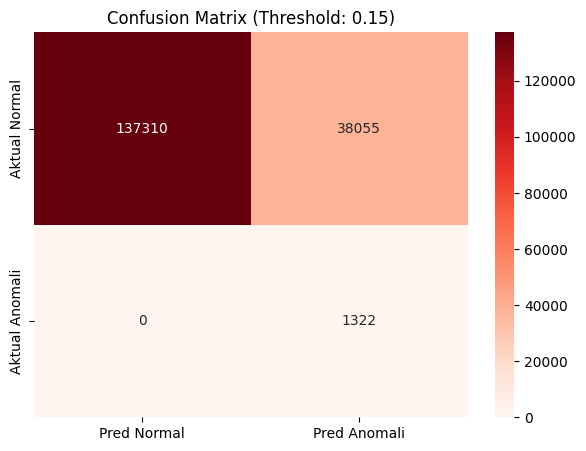

In [38]:
custom_threshold = 0.15

# Aturan baru: Jika skor di BAWAH threshold -> Anomali (1), selain itu -> Normal (0)
y_pred_custom = np.where(dfEval['anomaly_score'] < custom_threshold, 1, 0)

print(f"=== Evaluasi dengan Threshold Manual: {custom_threshold} ===")
print(classification_report(y_true, y_pred_custom, target_names=['Normal (0)', 'Anomali (1)']))

# Confusion Matrix Baru
cm_custom = confusion_matrix(y_true, y_pred_custom)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Pred Normal', 'Pred Anomali'], 
            yticklabels=['Aktual Normal', 'Aktual Anomali'])
plt.title(f'Confusion Matrix (Threshold: {custom_threshold})')
plt.show()

In [25]:
#save mode 
joblib.dump(iso_forest, 'model/model_isolation_forest.pkl')
joblib.dump(scaler, 'model/scaler_isola tion_forest.pkl')

['model/scaler_isola tion_forest.pkl']